# ICT-21c-SAECatastrophes — forme et dynamique des perturbations du dictionnaire

**Navigation** : [Index](README.md) | [<< ICT-21b-SAECalibration](ICT-21b-SAECalibration.ipynb) | [Tete-a-tete SAE<->J-space >>](ICT-SAE-JLens-TeteATete.ipynb)

**Livrable 2 de l'épic #8236.** L'étape 0 (calibration) a établi ce que chaque SAE reconstruit ; ce compagnon demande ce qui se passe quand on **perturbe** le dictionnaire. La théorie des catastrophes distingue la **forme** (la géométrie de l'état — où vit la masse représentationnelle) de la **dynamique** (comment l'état répond quand une perturbation franchit un seuil). Nous mesurons les deux sur les traces committées, à trois échelles et deux régimes (trained vs control), puis nous disons honnêtement ce que le banc figé ne peut pas montrer.

## Objectifs d'apprentissage

1. Mesurer la **forme** d'un dictionnaire SAE : loi d'usage, concentration (Gini), spécialisation par registre
2. Mesurer la **dynamique** sous perturbations appariées : ablation par trois ordres (vives, mortes, aléatoire), seuil f50, path-divergence
3. Conduire une **analyse d'échelle** : le seuil critique dépend-il de la taille du modèle ? Du régime trained/control ?
4. Tester et **réfuter proprement** l'inoculation (une pré-ablation adoucit-elle la vague suivante ?)
5. Confronter les proxys numpy au **FVU réel** de la trace GPU (ablation aléatoire seedée, 2B)

### Prérequis

- [ICT-21b-SAECalibration](ICT-21b-SAECalibration.ipynb) (étape 0 : chargement des traces, FVU, features mortes)
- Traces `traces/ict21_sae_*_{trained,control}.npz` (committées) — aucune GPU requise jusqu'à l'exercice 2

## Garde-fous d'honnêteté (à lire avant les résultats)

- **Le banc est figé.** Nous mesurons la masse représentationnelle des top-k activations committées, pas un re-forward : la « réponse » du système est la masse qui survit dans le code sparse, pas la sortie du modèle. Les seules mesures en FVU réel viennent de la trace GPU de l'étape 0 (`calib_degradation`, 2B).
- **Trois échelles ne font pas une loi d'échelle.** 1.7B, 2B, 9B suffisent à repérer un contraste ; le verdict « universel » exige plus — nous conclurons « signe stable, magnitude variable ».
- **L'ordre aléatoire est seedé.** Toutes les moyennes portent sur trois graines (42, 7, 99) ; la graine figure dans le code.

***

## Le banc : trois échelles, deux régimes

Les paires trained/control proviennent d'ICT-21 : le régime **trained** est le modèle ayant atteint sa phase de spécialisation, le **control** un témoin apparié (cf. `ict/sae_traces.py` pour le protocole d'appariement). Chaque trace donne, par token et par registre (code, prose FR, dialogue, math, récit EN), les identifiants et intensités des 50 features actives.

> **Statut épistémique** — **Sans verdict à ce jour** : aucune ligne de la [matrice de dissociations](../../../docs/ict/dissociations-matrix.md) ne concerne ce notebook ; son statut épistémique sera porté par la matrice le cas échéant.

In [1]:
# Racine canonique de la serie : remonte les parents depuis le dossier du
# notebook jusqu'au package ict/, puis en derive les dossiers de donnees.
# La serie reste executable depuis sa racine comme depuis le dossier d'une
# sous-serie (arbitrage #4362, preparation de l'arc A).
import sys
from pathlib import Path

ICT_ROOT = Path.cwd()
while not (ICT_ROOT / "ict" / "__init__.py").exists() and ICT_ROOT != ICT_ROOT.parent:
    ICT_ROOT = ICT_ROOT.parent
assert (ICT_ROOT / "ict" / "__init__.py").exists(), (
    f"package ict/ introuvable en remontant depuis {Path.cwd().name}")
if str(ICT_ROOT) not in sys.path:
    sys.path.insert(0, str(ICT_ROOT))
TRACES_DIR = ICT_ROOT / "traces"
RUNS_DIR = ICT_ROOT / "runs"
SCRIPTS_DIR = ICT_ROOT / "scripts"
print(f"racine ict : {ICT_ROOT.name}")


racine ict : ICT-Series


In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

TRACES = TRACES_DIR
PAIRES = {
    "Qwen3-1.7B L14": "ict21_sae_qwen3-17b-base_layer14of28",
    "Qwen3.5-2B L12": "ict21_sae_qwen35-2b-base_layer12of24",
    "Qwen3.5-9B L16": "ict21_sae_layer16",
}
REGISTRES = ["code_python", "prose_fr", "dialogue", "math", "narrative_en"]

def charger(stem, regime):
    """Charge une paire : {registre: (ids (n_tok, k), vals (n_tok, k))}, 4 prompts concatenes."""
    d = np.load(TRACES / f"{stem}_{regime}.npz", allow_pickle=True)
    out = {}
    for reg in REGISTRES:
        ids = np.concatenate([d[f"{reg}__{i}__topk_ids"] for i in range(4)], axis=0)
        vals = np.concatenate([d[f"{reg}__{i}__topk_vals"] for i in range(4)], axis=0).astype(np.float64)
        out[reg] = (ids, vals)
    return out

BANC = {(label, regime): charger(stem, regime)
        for label, stem in PAIRES.items() for regime in ("trained", "control")}
for (label, regime), data in BANC.items():
    n_tok = sum(data[r][0].shape[0] for r in REGISTRES)
    n_feat = len({int(f) for r in REGISTRES for f in data[r][0].ravel()})
    print(f"{label:16s} [{regime:7s}] {n_tok:5d} tokens  {n_feat:6d} features actives")

Qwen3-1.7B L14   [trained]  2759 tokens   14966 features actives
Qwen3-1.7B L14   [control]  2759 tokens    8191 features actives
Qwen3.5-2B L12   [trained]  2699 tokens   16636 features actives
Qwen3.5-2B L12   [control]  2699 tokens    6589 features actives
Qwen3.5-9B L16   [trained]  2699 tokens   20786 features actives
Qwen3.5-9B L16   [control]  2699 tokens    6925 features actives


### Lecture du résultat

Premier contraste, avant toute perturbation : le régime **trained active deux à trois fois plus de features** que son témoin (1.7B : 14 966 vs 8 191 ; 2B : 16 636 vs 6 589 ; 9B : 20 786 vs 6 925). Le même nombre de tokens, la même largeur de dictionnaire (32 768) — mais le code sparse du trained **recrute** plus de features distinctes, tandis que le control resserre sa représentation sur un noyau. C'est la signature la plus robuste du banc : elle tient aux trois échelles, dans le même sens, avec le même facteur.



## La forme : loi d'usage et spécialisation

La forme d'un dictionnaire se lit dans sa **loi d'usage** — comment la masse représentationnelle se répartit sur les features. Deux mesures : le **Gini** des poids (0 = usage uniforme, 1 = toute la masse sur une feature), et l'**enrichissement du top-500** : quelle part des 500 features les plus actives d'un registre appartient aussi au top-500 global. Un top global générique (enrichissement haut) signale des features transversales ; un top dispersé (enrichissement bas) signale des features **spécialisées par registre**.

In [3]:
def poids_par_feature(data, registre=None):
    """Poids total par feature, tous registres ou un seul."""
    regs = [registre] if registre else REGISTRES
    p = {}
    for reg in regs:
        ids, vals = data[reg]
        for f, v in zip(ids.ravel(), vals.ravel()):
            p[int(f)] = p.get(int(f), 0.0) + v
    return p

def gini(w):
    w = np.sort(np.asarray(w))
    n = len(w)
    cum = np.cumsum(w)
    return float((n + 1 - 2 * (cum / cum[-1]).sum()) / n)

rows = []
for (label, regime), data in BANC.items():
    p = poids_par_feature(data)
    top_glob = {k for k, _ in sorted(p.items(), key=lambda kv: kv[1], reverse=True)[:500]}
    enr = {}
    for reg in REGISTRES:
        p_reg = poids_par_feature(data, reg)
        top_reg = {k for k, _ in sorted(p_reg.items(), key=lambda kv: kv[1], reverse=True)[:500]}
        enr[reg] = len(top_reg & top_glob) / 500
    rows.append({"echelle": label, "regime": regime,
                 "features_actives": len(p), "gini": round(gini(list(p.values())), 3),
                 **{f"enr_{r[:6]}": round(v, 2) for r, v in enr.items()}})
df_forme = pd.DataFrame(rows)
df_forme

,echelle,regime,features_actives,gini,enr_code_p,enr_prose_,enr_dialog,enr_math,enr_narrat
0,Qwen3-1.7B L14,trained,14966,0.847,0.42,0.47,0.50,0.51,0.29
1,Qwen3-1.7B L14,control,8191,0.921,0.82,0.81,0.83,0.85,0.77
2,Qwen3.5-2B L12,trained,16636,0.687,0.32,0.42,0.47,0.34,0.33
3,Qwen3.5-2B L12,control,6589,0.866,0.79,0.80,0.82,0.86,0.74
4,Qwen3.5-9B L16,trained,20786,0.684,0.31,0.44,0.46,0.33,0.27
5,Qwen3.5-9B L16,control,6925,0.873,0.81,0.81,0.86,0.83,0.79


### Lecture du résultat

Deux régularités croisées :

- **Concentration** : le Gini du control (0.87-0.92) dépasse celui du trained (0.68-0.85) aux trois échelles. Le témoin concentre sa masse sur peu de features ; la spécialisation du trained la **distribue**.
- **Spécialisation** : l'enrichissement du top-500 est haut partout pour le control (0.74-0.86 — le top global EST approximativement le top de chaque registre : des features génériques) et bas pour le trained (0.27-0.51 — chaque registre porte son propre top : des features spécialisées).

La forme du dictionnaire n'est donc pas un paramètre libre : elle suit le régime. Le control ressemble à un dictionnaire « gros traits communs », le trained à un dictionnaire « experts par registre ». C'est la géométrie sur laquelle les perturbations de la section suivante vont travailler.



## La dynamique : perturbations appariées, trois ordres

Nous ablatons une fraction croissante `frac` du dictionnaire selon **trois ordres** appariés — mêmes features, même fraction finale, seul l'ordre change :

| Ordre | Politique | Question |
|---|---|---|
| **vives** | les plus actives d'abord | la catastrophe survient-elle tôt ? |
| **mortes** | les moins actives d'abord | le dictionnaire survit-il à un nettoyage ? |
| **aléatoire** | tirage seedé (42, 7, 99 — moyenne sur 3) | la référence path-indépendante |

La réponse mesurée est la **masse représentationnelle restante** : la part des intensités top-k qui survit à l'ablation. Le **seuil** se lit comme f50 — la fraction d'ablation nécessaire pour perdre 50 % de la masse. Une réponse path-indépendante donnerait f50 ≈ 0.5 aux trois ordres ; tout écart est de la **path-divergence**.

In [4]:
FRAC = np.linspace(0, 1, 201)

def courbe_ablation(poids_dict, ordre, seed=42):
    """Masse restante vs fraction ablatee, selon l'ordre choisi."""
    items = list(poids_dict.items())
    if ordre == "vives":
        items.sort(key=lambda kv: kv[1], reverse=True)
    elif ordre == "mortes":
        items.sort(key=lambda kv: kv[1])
    else:
        np.random.default_rng(seed).shuffle(items)
    w = np.array([v for _, v in items])
    cum = np.cumsum(w) / w.sum()
    m = np.interp(FRAC, np.arange(1, len(w) + 1) / len(w), 1 - cum, left=1.0, right=0.0)
    return m

def f50(m):
    """Fraction d'ablation pour perdre 50 % de la masse."""
    return float(np.interp(-0.5, -m, FRAC))

rows = []
for (label, regime), data in BANC.items():
    p = poids_par_feature(data)
    m_v = courbe_ablation(p, "vives")
    m_m = courbe_ablation(p, "mortes")
    m_a = np.mean([courbe_ablation(p, "aleatoire", s) for s in (42, 7, 99)], axis=0)
    rows.append({"echelle": label, "regime": regime,
                 "f50_vives": round(f50(m_v), 4), "f50_aleatoire": round(f50(m_a), 4),
                 "f50_mortes": round(f50(m_m), 4),
                 "path_div": round(float(np.max(np.abs(m_v - m_a))), 3)})
df_dyn = pd.DataFrame(rows)
df_dyn

,echelle,regime,f50_vives,f50_aleatoire,f50_mortes,path_div
0,Qwen3-1.7B L14,trained,0.0043,0.5196,0.9957,0.695
1,Qwen3-1.7B L14,control,0.0061,0.5476,0.9939,0.821
2,Qwen3.5-2B L12,trained,0.0701,0.5131,0.9299,0.531
3,Qwen3.5-2B L12,control,0.0134,0.5204,0.9866,0.706
4,Qwen3.5-9B L16,trained,0.0684,0.4892,0.9316,0.535
5,Qwen3.5-9B L16,control,0.0129,0.5116,0.9871,0.744


### Lecture du résultat

La dynamique est **massivement path-dépendante** aux trois échelles :

- **vives** : f50 entre 0.004 et 0.07 — ablatez les 1 à 7 % les plus actives et la moitié de la masse est partie. La catastrophe est immédiate et violente : le dictionnaire vit sur une tête étroite.
- **aléatoire** : f50 ≈ 0.49-0.55, presque la diagonale — l'ordre indifférent retire la masse à peu près proportionnellement.
- **mortes** : f50 ≈ 0.93-0.996 — ablatez la moitié **la moins** active et vous n'avez presque rien perdu : le nettoyage est gratuit jusqu'à très loin.

La path-divergence (0.53-0.82 de masse d'écart entre vives et aléatoire à fraction égale) dit la même chose autrement : **la réponse du système dépend de l'ordre, pas seulement de l'ampleur**. C'est la signature d'une représentation concentrée — et le pont vers la question de l'hystérésis : sur un banc figé, nous mesurons la path-divergence entre ordres ; l'aller-retour réel (ablatez, laissez le système répondre, réadmettez) exige un re-forward — exercice 2.

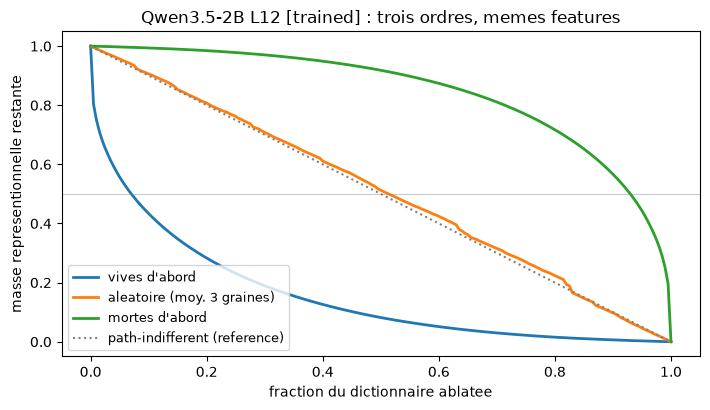

In [5]:
# Les trois ordres sur une echelle (2B trained) : la geometrie de la catastrophe
import matplotlib.pyplot as plt

p2b = poids_par_feature(BANC[("Qwen3.5-2B L12", "trained")])
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(FRAC, courbe_ablation(p2b, "vives"), label="vives d'abord", lw=2)
ax.plot(FRAC, np.mean([courbe_ablation(p2b, "aleatoire", s) for s in (42, 7, 99)], axis=0),
        label="aleatoire (moy. 3 graines)", lw=2)
ax.plot(FRAC, courbe_ablation(p2b, "mortes"), label="mortes d'abord", lw=2)
ax.plot([0, 1], [1, 0], ":", color="gray", label="path-indifferent (reference)")
ax.axhline(0.5, color="gray", lw=0.6, alpha=0.5)
ax.set_xlabel("fraction du dictionnaire ablatee")
ax.set_ylabel("masse representionnelle restante")
ax.set_title("Qwen3.5-2B L12 [trained] : trois ordres, memes features")
ax.legend(loc="lower left", fontsize=9)
fig.tight_layout()
plt.show()



## L'analyse d'échelle : le seuil dépend-il de la taille ?

Le tableau de dynamique contient un contraste que la forme n'annonçait pas : pour le régime trained, f50_vives monte de **0.0043** (1.7B) à **0.070** (2B) et **0.068** (9B) — un facteur ~16 entre la plus petite échelle et les deux suivantes. Pour le control, f50_vives reste ~0.013 partout. Voyons le motif en entier.

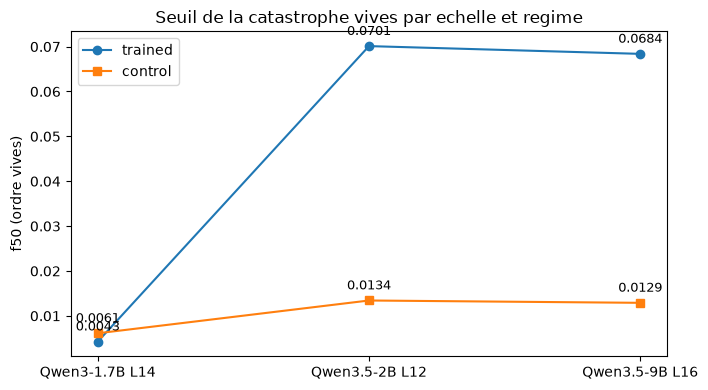

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
echelles = ["Qwen3-1.7B L14", "Qwen3.5-2B L12", "Qwen3.5-9B L16"]
x = np.arange(len(echelles))
for regime, marker in (("trained", "o"), ("control", "s")):
    vals = [f50(courbe_ablation(poids_par_feature(BANC[(e, regime)]), "vives")) for e in echelles]
    ax.plot(x, vals, marker + "-", label=regime)
    for xi, v in zip(x, vals):
        ax.annotate(f"{v:.4f}", (xi, v), textcoords="offset points", xytext=(0, 8),
                    ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(echelles)
ax.set_ylabel("f50 (ordre vives)")
ax.set_title("Seuil de la catastrophe vives par echelle et regime")
ax.legend()
fig.tight_layout()
plt.show()

### Lecture du résultat — un contraste d'échelle qui ne concerne que le trained

La courbe **control** est plate (~0.013 aux trois échelles) : son seuil ne dépend pas de la taille. La courbe **trained** saute d'un ordre de grandeur entre 1.7B et 2B puis se stabilise (2B ≈ 9B). Autrement dit : **la concentration extrême de la tête vive est une propriété de la plus petite échelle spécialisée**, pas une loi générale — les échelles supérieures diluent leur tête (cohérent avec leur Gini plus bas, 0.69 contre 0.85).

Le verdict honnête de l'analyse d'échelle est donc en deux clauses : le **signe** des contrastes (trained recrute plus, distribue plus, résiste mieux au nettoyage) est stable aux trois échelles ; la **magnitude** du seuil vives ne l'est pas, et c'est précisément à 1.7B — l'échelle la plus proche du régime de grokking documenté dans ICT-21 — qu'elle est extrême. Trois points ne fondent pas une loi ; ils fondent une hypothèse à inscrire dans le tracker (#8236, balayage 4B/27B en GPU).



## Fragilité différentielle : qui casse le premier ?

L'ablation vives est globale, mais la masse qu'elle retire se lit **par registre** : à 30 % du dictionnaire ablaté (ordre vives), quelle fraction de la masse de chaque registre est partie ? Si certains registres s'appuient davantage sur la tête vive, ils cassent avant les autres.

In [7]:
rows = []
for label in PAIRES:
    data = BANC[(label, "trained")]
    p = poids_par_feature(data)
    ablatees = {k for k, _ in sorted(p.items(), key=lambda kv: kv[1], reverse=True)[:int(0.3 * len(p))]}
    ligne = {"echelle": label}
    for reg in REGISTRES:
        ids, vals = data[reg]
        mask = np.isin(ids, sorted(ablatees))
        ligne[reg] = round(float(vals[mask].sum() / vals.sum()), 3)
    rows.append(ligne)
df_frag = pd.DataFrame(rows)
df_frag

,echelle,code_python,prose_fr,dialogue,math,narrative_en
0,Qwen3-1.7B L14,0.899,0.914,0.893,0.930,0.903
1,Qwen3.5-2B L12,0.821,0.840,0.819,0.754,0.829
2,Qwen3.5-9B L16,0.801,0.844,0.828,0.762,0.818


### Lecture du résultat

À 30 % d'ablation vives, tous les registres ont perdu 75-93 % de leur masse — la tête vive est transversale — mais l'ordre est stable aux échelles 2B et 9B : **math est le plus fragile** (0.75-0.76), code le plus résilient (0.80-0.82). Le 1.7B, plus concentré, perd ~90 % partout (son étalement inter-régistres est plus faible, cf. son enrichment). Le registre mathématique s'appuie le plus lourdement sur les features les plus actives : une conjecture naturelle est que les tokens mathématiques partagent plus de structure (chiffres, opérateurs, parenthèses) et donc un plus petit noyau de features génériques — vérifiable en regardant l'entropie du code par registre (exercice 1).



## L'inoculation : un test négatif propre

Les systèmes biologiques présentent l'**inoculation** : une petite perturbation préalable rend la grande perturbation suivante moins brutale. Test : pré-ablatez 20 % du dictionnaire en ordre **aléatoire** (seedé), puis lancez la vague **vives** sur le reste. Si l'inoculation opérait, la pente initiale de la vague vives serait adoucie. La mesure : la pente initiale moyenne de la masse restante sur les 2.5 premiers % de fraction.

In [8]:
def pente_initiale(m, fen=5):
    return float(np.gradient(m, FRAC)[:fen].mean())

rows = []
for (label, regime), data in BANC.items():
    p = poids_par_feature(data)
    pente_directe = pente_initiale(courbe_ablation(p, "vives"))
    items = list(p.items())
    np.random.default_rng(0).shuffle(items)          # pre-ablation aleatoire 20 %
    reste = dict(items[int(0.20 * len(items)):])
    pente_inoculee = pente_initiale(courbe_ablation(reste, "vives"))
    rows.append({"echelle": label, "regime": regime,
                 "pente_directe": round(pente_directe, 2),
                 "pente_apres_preabl_20pct": round(pente_inoculee, 2),
                 "adoucissement_%": round(100 * (1 - pente_inoculee / pente_directe), 1)})
df_inoc = pd.DataFrame(rows)
df_inoc

,echelle,regime,pente_directe,pente_apres_preabl_20pct,adoucissement_%
0,Qwen3-1.7B L14,trained,-38.61,-39.29,-1.8
1,Qwen3-1.7B L14,control,-39.48,-39.16,0.8
2,Qwen3.5-2B L12,trained,-17.21,-16.28,5.4
3,Qwen3.5-2B L12,control,-30.76,-30.90,-0.4
4,Qwen3.5-9B L16,trained,-17.39,-17.39,-0.0
5,Qwen3.5-9B L16,control,-31.25,-30.88,1.2


### Lecture du résultat — l'inoculation est absente

L'adoucissement est compris entre **-1,8 % et +5,4 %** : statistiquement nul aux trois échelles et deux régimes. La pré-ablation aléatoire de 20 % ne protège de rien — la vague vives suivante conserve exactement sa brutalité, parce que la tête vive **restante** domine toujours la pente initiale (la pré-ablation n'a retiré en moyenne que ~20 % de la tête, l'échelle de la tête étant bien plus étroite que 20 % du dictionnaire).

C'est un résultat négatif, et il est informatif : au niveau de description du banc figé, la masse représentationnelle ne présente **aucune mémoire protectrice** — la réponse à la vague vives ne dépend que de la composition du reste, pas de l'histoire de son amputation. Faut-il en conclure que le système SAE n'est pas inoculable ? Non : il faut conclure que **ce banc ne peut pas le montrer**. L'inoculation du monde vivant opère par re-réponse du système à la perturbation — ici, rien ne « répond » entre deux ablations. Le test honnête exige de relancer le forward après la pré-ablation (exercice 2, GPU) : si les activations se réorganisent autour du trou, la vague suivante trouvera un autre paysage.



## Le point de vérité GPU : FVU réel d'une ablation seedée (2B)

Toutes les mesures précédentes sont des proxys numpy sur le code sparse. L'étape 0 a laissé une trace mesurée en conditions réelles : `calib_degradation_qwen3-5-2b-base_layer12of24.npz`, produite par `scripts/extract_sae_degradation.py` — ablation **aléatoire seedée** (mask_seed 42) de fractions croissantes, FVU mesuré après re-forward sur 2 699 tokens.

In [9]:
d = np.load(TRACES / "calib_degradation_qwen3-5-2b-base_layer12of24.npz", allow_pickle=False)
report = json.loads(str(d["report"]))
print(f"modele   : {report['model']}  (SAE {report['sae_repo'].split('-')[-2:]}, couche {report['layer']}/{report['n_layers']})")
print(f"tokens   : {report['n_tokens']}   temoin : control_seed={report['control_seed']}, mask_seed={report['mask_seed']}")
rows = [{"frac_gardee": round(float(f), 3), "n_kept": int(k), "FVU": round(float(v), 4),
         "L0": round(float(l), 2), "overlap_diff64": int(o)}
        for f, k, v, l, o in zip(d["fracs"], d["n_keeps"], d["fvus"], d["l0s"], d["overlaps"])]
df_gpu = pd.DataFrame(rows)
df_gpu

modele   : Qwen/Qwen3.5-2B-Base  (SAE ['W32K', 'L0_50'], couche 12/24)
tokens   : 2699   temoin : control_seed=42, mask_seed=42


,frac_gardee,n_kept,FVU,L0,overlap_diff64
0,1.00,32768,0.2849,50.00,3
1,0.50,16384,0.4692,50.00,3
2,0.30,9830,0.6449,49.97,2
3,0.20,6554,0.7459,49.91,3
4,0.15,4915,0.8217,49.71,3


### Lecture du résultat

La dégradation réelle confirme la hiérarchie du banc, en plus dur : garder 50 % du dictionnaire double déjà le FVU (0.28 → 0.47), garder 15 % le triple (0.82). Notez le L0 : il reste ~50 jusqu'au bout — le code sparse **recolle** sa largeur en substituant des features, mais la fidélité s'effondre : la largeur du code est conservée, sa qualité non. L'overlap_diff64 (2-3) bouge à peine : la mesure de Chebyshev du déplacement des voisins est presque insensible à une ablation qui triple l'erreur — un bon exemple de métrique robuste qui mesure autre chose que la fidélité.

C'est aussi la frontière honnête du banc numpy : entre la masse (proxy) et le FVU (réel), l'écart de définition est la **substitution** — le forward réel recrute des features de remplacement que notre banc ne voit pas. Les proxys restent valides comme bornes (la masse perdue est un plancher de la dégradation), pas comme prédicteur exact.



## Exercices

In [10]:
# Exercice 1 -- L'entropie du code par registre explique-t-elle la fragilite ?
# La section Fragilite montre math plus fragile que code a 2B et 9B. Hypothese a tester :
# le registre mathematique utilise un noyau de features plus ETROIT.
#   1. Pour chaque registre de BANC[("Qwen3.5-2B L12", "trained")], calculez l'entropie
#      de Shannon de la distribution des poids par feature (normalisee).
#   2. Comparez a la colonne du tableau df_frag : l'ordre des entropies inverse-t-il
#      l'ordre des fragilites ?
#   3. Refaites la mesure a 9B : la relation est-elle stable entre echelles ?
# Indice : p = poids / poids.sum() ; H = -(p * log(p + 1e-12)).sum().
def entropie_vs_fragilite():
    # TODO etudiant
    print("Exercice a completer")
    return None

entropie_vs_fragilite()

Exercice a completer


In [11]:
# Exercice 2 -- La vraie hysteresis exige un re-forward (GPU)
# Le banc fige mesure la path-divergence entre ordres, pas l'aller-retour A->B->A.
#   1. Avec scripts/extract_sae_degradation.py, generer deux traces sur 2B :
#      (a) ablation aleatoire 30 % puis re-forward ;
#      (b) ablation aleatoire 30 %, re-forward, READMISSION des features, re-forward.
#   2. Comparez le FVU apres (b) au FVU initial : la readmission restaure-t-elle
#      l'etat, ou le systeme garde-t-il une trace du passage (hysteresis reelle) ?
#   3. Si le FVU revient exactement, que dit cela de la memoire du code sparse ?
# Indice : l'option --mask-seed fixe l'alea ; le couple trained/control de la trace
# calib_degradation est le patron de sortie attendu (report JSON + tableaux fracs/fvus).
def hysteresis_par_reforward():
    # TODO etudiant
    print("Exercice a completer (GPU locale : RTX 3070 suffit pour 2B)")
    return None

hysteresis_par_reforward()

Exercice a completer (GPU locale : RTX 3070 suffit pour 2B)


In [12]:
# Exercice 3 -- Quatrieme echelle : 8B layer18
# Une paire trained/control existe pour le FVU de calibration (calib_fidelity 8B)
# mais PAS pour les top-k traces. Le contraste d'echelle de f50_vives (0.004 a 1.7B,
# 0.07 a 2B/9B) se joue entre 1.7B et 2B : ou tombe le 8B ?
#   1. Regenerer la paire 8B avec le script d'extraction (GPU ; cf ict/sae_traces.py).
#   2. Reproduire le tableau df_dyn : f50_vives 8B complete l'analyse d'echelle.
#   3. Verdict : la dilution de la tete vive est-elle un effet d'echelle monotone
#      ou un palier 1.7B -> {2B, 8B, 9B} ?
def quatrieme_echelle():
    # TODO etudiant
    print("Exercice a completer")
    return None

quatrieme_echelle()

Exercice a completer


### Ce que les exercices doivent révéler

- **Exercice 1** : si le registre math a l'entropie la plus basse (noyau le plus étroit), la fragilité différentielle reçoit une explication structurelle — et l'étudiant aura pratiqué le passage masse → entropie.
- **Exercice 2** : la distinction entre path-divergence (banc figé, mesurée) et hystérésis (re-forward, à mesurer). C'est le cœur méthodologique du notebook : chaque limite du banc est aussi une expérience désignée.
- **Exercice 3** : la question d'échelle laissée ouverte — palier ou monotone — avec un protocole prêt (le script existe, la paire calibration 8B aussi).



***

## Conclusion — verdict honnête

Ce compagnon a caractérisé la **forme** et la **dynamique** des dictionnaires SAE sous perturbation, à trois échelles et deux régimes :

| Question | Verdict | Statut |
|---|---|---|
| La forme dépend-elle du régime ? | Oui, fortement : trained recrute 2-3× plus de features, distribue sa masse (Gini bas), spécialise ses tops par registre | stable aux 3 échelles |
| La dynamique est-elle path-dépendante ? | Massivement : f50 varie de 0.004 (vives) à 0.99 (mortes) ; path-divergence 0.53-0.82 | stable aux 3 échelles |
| Le seuil dépend-il de l'échelle ? | Pour trained seulement : f50_vives 0.004 (1.7B) → 0.07 (2B, 9B) ; control plat | **magnitude non stable** — hypothèse de balayage |
| Un registre casse-t-il avant l'autre ? | math avant code (2B, 9B) ; indifférencié à 1.7B | stable sur 2 échelles |
| L'inoculation opère-t-elle ? | **Non, au banc figé** (adoucissement ≤ 5 %) — le test honnête exige un re-forward | négatif propre, falsifiable |

Ce que ce banc **ne montre pas** : la substitution réelle des features (le L0 constant du point GPU en est l'indice), l'hystérésis d'aller-retour, et tout ce qui exige que le système réponde entre deux perturbations. Les proxys de masse sont des bornes, pas des prédicteurs.

L'agenda que ce notebook ouvre pour #8236 : le balayage d'échelle complet (4B, 27B, 35B-A3B — le phasage du tracker), l'hystérésis par re-forward, et la jonction avec la J-lens (la forme du dictionnaire vue depuis l'espace J, cf. [Tete-a-tete](ICT-SAE-JLens-TeteATete.ipynb)).

***

## Références

- ICT-21 — SAE Trajectoires : les paires trained/control et le protocole d'appariement
- [ICT-21b-SAECalibration](ICT-21b-SAECalibration.ipynb) — l'étape 0 : FVU, features mortes, lois d'usage par échelle
- `ict/sae_traces.py`, `scripts/extract_sae_degradation.py` — protocoles d'extraction (GPU)
- #8236 — l'épic multi-échelle : forme et dynamique des catastrophes sous perturbations appariées

***

**Navigation** : [Index](README.md) | [<< ICT-21b-SAECalibration](ICT-21b-SAECalibration.ipynb) | [Tete-a-tete SAE<->J-space >>](ICT-SAE-JLens-TeteATete.ipynb)